   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

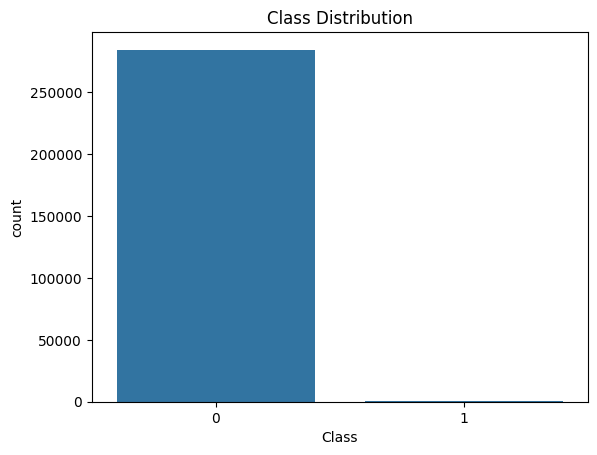

       Time        V1        V2        V3        V4        V5        V6  \
0 -1.996583 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1 -1.996583  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2 -1.996562 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3 -1.996562 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4 -1.996541 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.239599  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928   
1 -0.078803  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.791461  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.237609  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575   
4  0.592941 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27       V28    Amount  Class  
0  0.12

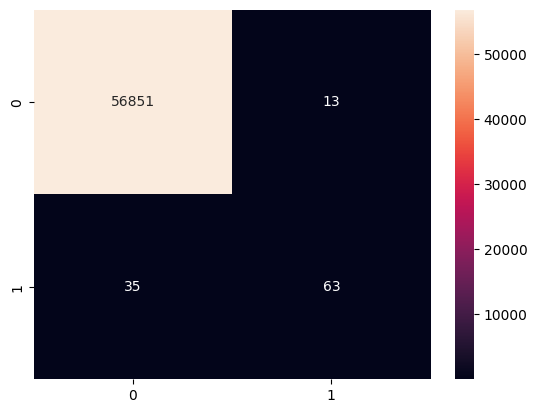

====DecisionTreeClassifier====
0.9994557775359011
precision 0.8941176470588236
confusion metrics: [[56855     9]
 [   22    76]]
Recall: 0.7755102040816326
F1 Score: 0.8306010928961749
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score,f1_score,precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
df=pd.read_csv("creditcard.csv", on_bad_lines='skip', low_memory=False)
print(df.head())
print(df.info())
df.isnull().sum()
print("Duplicate Rows:", df.duplicated())
print(df["Class"].value_counts())
df.describe()
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

# Drop rows where 'Class' is NaN before scaling and splitting
df.dropna(subset=['Class'], inplace=True)

Scaler=StandardScaler()
df["Amount"]=Scaler.fit_transform(df[["Amount"]])
df["Time"]=Scaler.fit_transform(df[["Time"]])
print(df.head())
X=df.drop("Class",axis=1)
y=df["Class"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print("====LogisticRegression====")
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.show()
#Decision tree
dt=DecisionTreeClassifier(max_depth=5)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)
print("====DecisionTreeClassifier====")
print(accuracy_score(y_test,y_pred))
print("precision",precision_score(y_test,y_pred))
print("confusion metrics:",confusion_matrix(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Classification Report:")
print(classification_report(y_test,y_pred))
#random forest
rf=RandomForestClassifier(n_estimators=100,max_depth=5)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
print("====RandomForestClassifier====")
print(accuracy_score(y_test,y_pred))
print("precision",precision_score(y_test,y_pred))
print("confusion metrics:",confusion_matrix(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Classification Report:")
print(classification_report(y_test,y_pred))
models = {
    "LogisticRegression"     : lr,
    "DecisionTreeClassifier" : dt,
    "RandomForestClassifier" : rf,
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    results.append({
        "Model"    : name,
        "Accuracy" : accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall"   : recall_score(y_test, preds),
        "F1 Score" : f1_score(y_test, preds)
    })

df = pd.DataFrame(results)
print(df)
importance=rf.feature_importances_
features=X.columns
importance_df=pd.DataFrame({"Features":features,"Importance":importance})
importance_df=importance_df.sort_values(by="Importance",ascending=False)
print(importance_df.head(10))
import joblib
joblib.dump(rf,"credit_card_model.pkl")
print("Model Saved Successfully")